# Enhanced Data Analysis Notebook

This notebook provides enhanced analysis of topology experiments with:
1. **Multi-Seed Figure6 Plots** - Direct topology comparison with transparency
2. **Enhanced Summary Table** - Including variance and standard deviation analysis
3. **Statistical Analysis** - Comprehensive variance between seeds

## Key Features
- **Overlay Plotting**: All topologies on same plot with different colors and transparency
- **Variance Analysis**: Standard deviation and variance calculations across seeds
- **Enhanced Summary**: Statistical metrics in cumulative reward table

## Data Source
All data is loaded from local `test_experiments/` folders generated during training runs.


In [16]:
# Import required libraries
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("✅ Libraries imported successfully")


✅ Libraries imported successfully


In [17]:
# ============================================================================
# ENHANCED UTILITY FUNCTIONS
# ============================================================================

# "cartpole/N0002/S256/"
# "acrobot/N0001/S384/"
# "lunarlander/N0003/S256/"


def load_training_data(base_path: str = "acrobot/N0001/S128") -> Dict:
    """Load all training data from local folders."""
    if not os.path.exists(base_path):
        print(f"❌ Directory {base_path} not found")
        return {}
    
    topology_groups = {}
    
    # Scan all directories
    for item in os.listdir(base_path):
        item_path = os.path.join(base_path, item)
        if not os.path.isdir(item_path):
            continue
            
        # Try to load metadata
        metadata_file = os.path.join(item_path, "run_metadata.json")
        if not os.path.exists(metadata_file):
            continue
            
        try:
            with open(metadata_file, 'r') as f:
                metadata = json.load(f)
            
            # Extract topology type and seed
            if 'training_config' in metadata:
                config = metadata['training_config']
                topology_type = config.get('topology_type', 'unknown')
                seed = config.get('seed', 'unknown')
                task_name = config.get('task_name', 'unknown')
                
                # Create topology group key (excluding seed)
                topology_key = f"{task_name}_{topology_type}"
                
                if topology_key not in topology_groups:
                    topology_groups[topology_key] = {
                        'runs': [],
                        'task_name': task_name,
                        'topology_type': topology_type,
                        'metadata': metadata
                    }
                
                # Load episode data
                episode_file = os.path.join(item_path, "data", "episode_data.csv")
                if os.path.exists(episode_file):
                    episode_data = pd.read_csv(episode_file)
                    
                    topology_groups[topology_key]['runs'].append({
                        'seed': seed,
                        'folder': item,
                        'episode_data': episode_data,
                        'metadata': metadata
                    })
                    
        except Exception as e:
            print(f"⚠️  Error loading {item}: {e}")
            continue
    
    # Sort runs by seed for each topology
    for topology_key in topology_groups:
        topology_groups[topology_key]['runs'].sort(key=lambda x: x['seed'])
    
    print(f"✅ Loaded data for {len(topology_groups)} topology types:")
    for topology_key, group in topology_groups.items():
        print(f"   📊 {topology_key}: {len(group['runs'])} seeds")
    
    return topology_groups

def group_episodes_by_iteration(episode_data: pd.DataFrame) -> pd.DataFrame:
    """Group episodes by iteration and calculate mean episode reward per iteration."""
    if 'episode_return_raw' not in episode_data.columns:
        print("⚠️  No episode_return_raw column found")
        return pd.DataFrame()
    
    # Calculate iteration number (each iteration has 2 episodes)
    episode_data = episode_data.copy()
    episode_data['iteration'] = (episode_data.index // 2) + 1
    
    # Group by iteration and calculate mean episode reward
    iteration_data = episode_data.groupby('iteration').agg({
        'episode_return_raw': 'mean',  # Mean episode reward per iteration
        'episode_length': 'mean',      # Mean episode length per iteration
        'global_step_end': 'max'      # Max global step for this iteration
    }).reset_index()
    
    return iteration_data

def apply_window_smoothing(data: np.ndarray, window: int = 10) -> np.ndarray:
    """Apply window smoothing to data."""
    if len(data) < window:
        return data
    
    smoothed = np.convolve(data, np.ones(window)/window, mode='valid')
    # Pad the beginning to maintain array length
    padding = np.full(window-1, smoothed[0])
    return np.concatenate([padding, smoothed])

def calculate_enhanced_statistics(data_arrays: List[np.ndarray], confidence: float = 0.95) -> Dict:
    """Calculate enhanced statistics including variance and standard deviation."""
    if not data_arrays:
        return {}
    
    # Stack arrays and calculate statistics
    stacked = np.vstack(data_arrays)
    mean = np.mean(stacked, axis=0)
    std = np.std(stacked, axis=0, ddof=1)  # Sample standard deviation
    var = np.var(stacked, axis=0, ddof=1)  # Sample variance
    
    # Calculate confidence intervals
    n = len(data_arrays)
    if n > 1:
        from scipy import stats
        t_value = stats.t.ppf((1 + confidence) / 2, n - 1)
        margin = t_value * std / np.sqrt(n)
    else:
        margin = np.zeros_like(std)
    
    lower_bound = mean - margin
    upper_bound = mean + margin
    
    return {
        'mean': mean,
        'std': std,
        'var': var,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'n_seeds': n,
        'cv': std / np.abs(mean + 1e-8)  # Coefficient of variation
    }

print("✅ Enhanced utility functions defined")


✅ Enhanced utility functions defined


In [18]:
# Load training data
print("🔄 Loading training data...")
topology_groups = load_training_data()

if not topology_groups:
    print("❌ No training data found. Please run some training experiments first.")
else:
    print(f"✅ Loaded {len(topology_groups)} topology groups")


🔄 Loading training data...
✅ Loaded data for 4 topology types:
   📊 Acrobot-v1_modular: 3 seeds
   📊 Acrobot-v1_small_world: 2 seeds
   📊 Acrobot-v1_standard_mlp: 2 seeds
   📊 Acrobot-v1_hybrid: 2 seeds
✅ Loaded 4 topology groups


In [19]:
# ============================================================================
# SECTION 1: ENHANCED FIGURE6 OVERLAY PLOT
# ============================================================================

def prepare_enhanced_figure6_data(topology_groups: Dict) -> Dict:
    """Prepare data for enhanced Figure6 plots with variance analysis."""
    figure6_data = {}
    
    for topology_key, group in topology_groups.items():
        if len(group['runs']) < 2:
            print(f"⚠️  Skipping {topology_key}: Need at least 2 seeds for aggregation")
            continue
        
        # Extract iteration-based rewards for each seed
        seed_rewards = []
        max_iterations = 0
        
        for run in group['runs']:
            episode_data = run['episode_data']
            
            # Group episodes by iteration and calculate mean episode reward per iteration
            iteration_data = group_episodes_by_iteration(episode_data)
            
            if not iteration_data.empty and 'episode_return_raw' in iteration_data.columns:
                rewards = iteration_data['episode_return_raw'].values
                seed_rewards.append(rewards)
                max_iterations = max(max_iterations, len(rewards))
            else:
                print(f"⚠️  No valid iteration data in {run['folder']}")
        
        if not seed_rewards:
            continue
        
        # Pad arrays to same length and apply smoothing
        padded_rewards = []
        for rewards in seed_rewards:
            if len(rewards) < max_iterations:
                # Pad with last value
                padded = np.pad(rewards, (0, max_iterations - len(rewards)), 
                               mode='edge')
            else:
                padded = rewards[:max_iterations]
            
            # Apply window=5 smoothing
            smoothed = apply_window_smoothing(padded, window=8)
            padded_rewards.append(smoothed)
        
        # Calculate enhanced statistics
        stats = calculate_enhanced_statistics(padded_rewards)
        
        figure6_data[topology_key] = {
            'iterations': np.arange(1, max_iterations + 1),
            'mean_rewards': stats['mean'],
            'std_rewards': stats['std'],
            'var_rewards': stats['var'],
            'lower_bound': stats['lower_bound'],
            'upper_bound': stats['upper_bound'],
            'cv': stats['cv'],
            'num_seeds': stats['n_seeds'],
            'topology_type': group['topology_type'],
            'task_name': group['task_name']
        }
    
    return figure6_data

# Prepare enhanced Figure6 data
print("🔄 Preparing enhanced Figure6 data with variance analysis...")
figure6_data = prepare_enhanced_figure6_data(topology_groups)
print(f"✅ Prepared enhanced data for {len(figure6_data)} topology types")


🔄 Preparing enhanced Figure6 data with variance analysis...
✅ Prepared enhanced data for 4 topology types


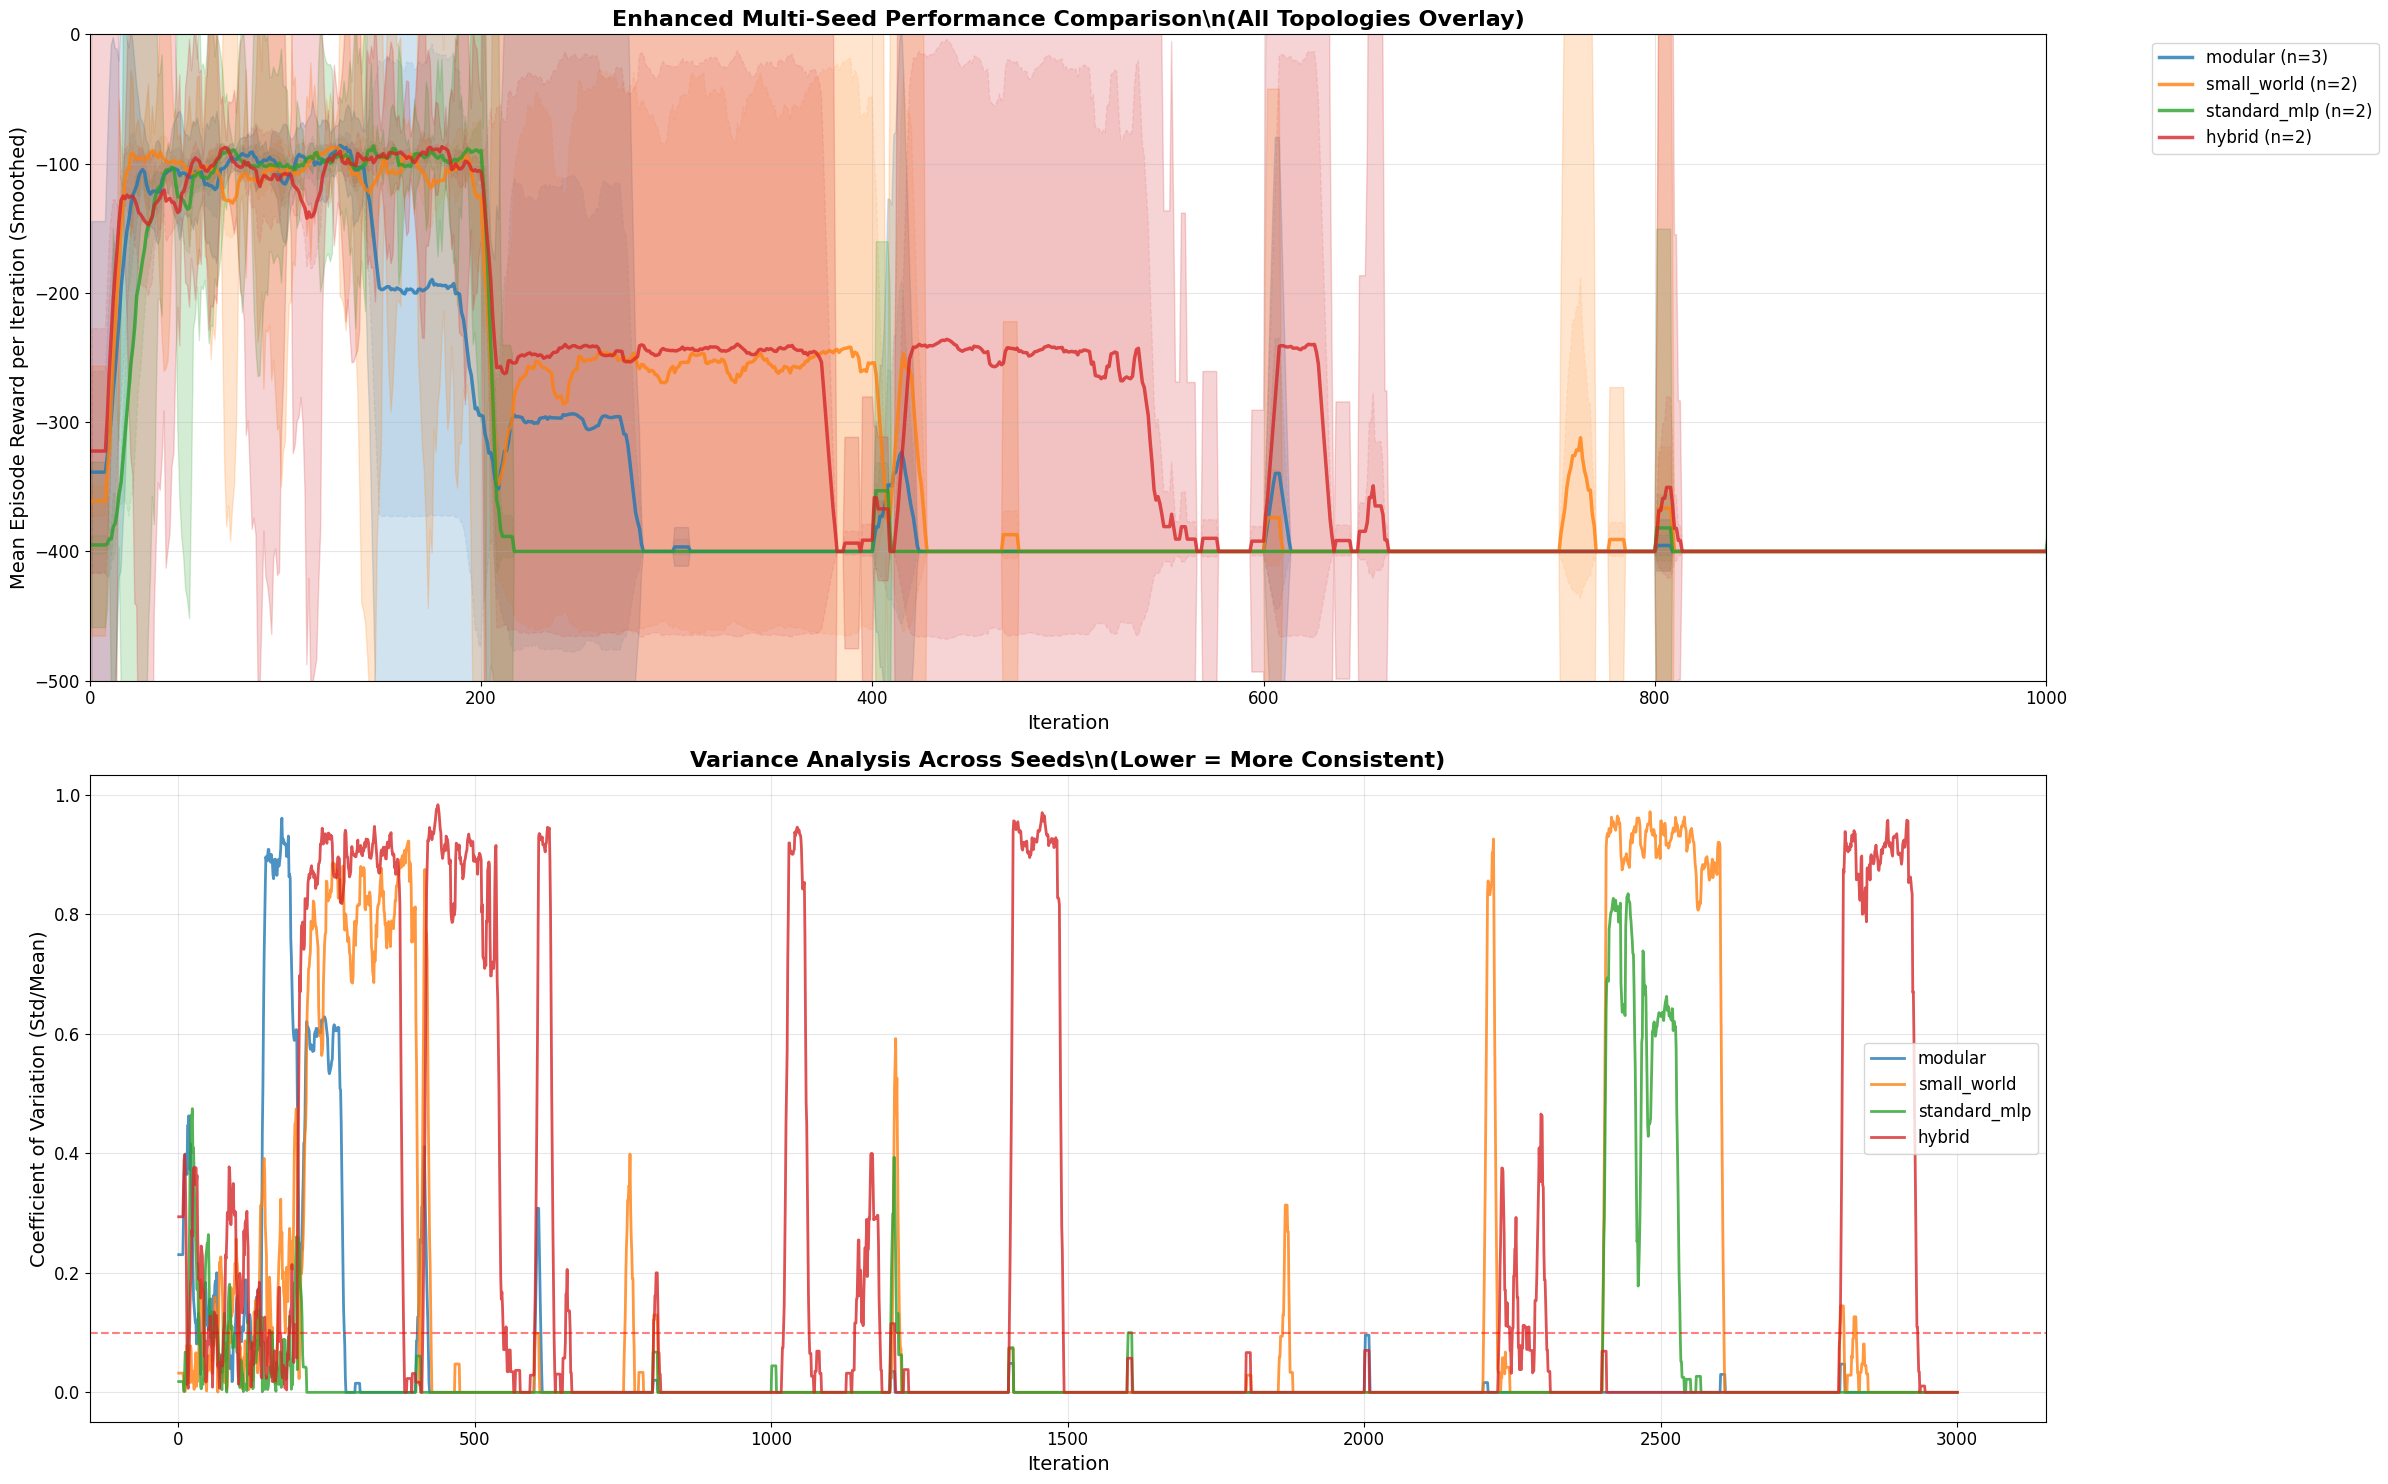

✅ Enhanced Figure6 overlay plots generated


In [20]:
def plot_enhanced_figure6_overlay(figure6_data: Dict):
    """Create enhanced Figure6 overlay plot with transparency and variance."""
    if not figure6_data:
        print("❌ No Figure6 data available")
        return
    
    # Define colors for each topology
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
    
    # Create main overlay plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 15))
    
    # Plot 1: Overlay all topologies with transparency
    for i, (topology_key, data) in enumerate(figure6_data.items()):
        iterations = data['iterations']
        mean_rewards = data['mean_rewards']
        std_rewards = data['std_rewards']
        lower_bound = data['lower_bound']
        upper_bound = data['upper_bound']
        
        color = colors[i % len(colors)]
        
        # Plot mean line with transparency
        ax1.plot(iterations, mean_rewards, 
                label=f"{data['topology_type']} (n={data['num_seeds']})", 
                color=color, linewidth=2.5, alpha=0.8)
        
        # Plot confidence interval with transparency
        ax1.fill_between(iterations, lower_bound, upper_bound, 
                        alpha=0.2, color=color)
        
        # Plot standard deviation band
        ax1.fill_between(iterations, mean_rewards - std_rewards, mean_rewards + std_rewards, 
                        alpha=0.1, color=color, linestyle='--')
    
    ax1.set_xlabel('Iteration', fontsize=14)
    ax1.set_ylabel('Mean Episode Reward per Iteration (Smoothed)', fontsize=14)
    ax1.set_title('Enhanced Multi-Seed Performance Comparison\\n(All Topologies Overlay)', fontsize=16, fontweight='bold')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(-500, 0)
    ax1.set_xlim(0, 1000)
    # ax1.set_xlim(0, 1500)
    
    # Plot 2: Variance analysis
    for i, (topology_key, data) in enumerate(figure6_data.items()):
        iterations = data['iterations']
        cv = data['cv']  # Coefficient of variation
        
        color = colors[i % len(colors)]
        
        ax2.plot(iterations, cv, 
                label=f"{data['topology_type']}", 
                color=color, linewidth=2, alpha=0.8)
    
    ax2.set_xlabel('Iteration', fontsize=14)
    ax2.set_ylabel('Coefficient of Variation (Std/Mean)', fontsize=14)
    ax2.set_title('Variance Analysis Across Seeds\\n(Lower = More Consistent)', fontsize=16, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='Low Variance Threshold')
    # ax1.set_xlim(0, 1500)
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Enhanced Figure6 overlay plots generated")

# Generate enhanced Figure6 plots
plot_enhanced_figure6_overlay(figure6_data)


In [21]:
# ============================================================================
# SECTION 2: ENHANCED SUMMARY TABLE WITH VARIANCE
# ============================================================================

def calculate_enhanced_cumulative_rewards(figure6_data: Dict) -> pd.DataFrame:
    """Calculate enhanced cumulative rewards with variance analysis."""
    cumulative_data = []
    
    for topology_key, data in figure6_data.items():
        iterations = data['iterations']
        mean_rewards = data['mean_rewards']
        std_rewards = data['std_rewards']
        var_rewards = data['var_rewards']
        
        # Calculate cumulative sum
        cumulative_rewards = np.cumsum(mean_rewards)
        
        # Calculate cumulative variance (sum of variances)
        cumulative_var = np.cumsum(var_rewards)
        cumulative_std = np.sqrt(cumulative_var)
        
        # Store key milestones
        milestones = [50, 100, 200, 500, 1000, 1500, 2000, 2500, 3000]
        milestone_data = {}
        
        for milestone in milestones:
            if milestone <= len(iterations):
                idx = milestone - 1
                milestone_data[f'iteration_{milestone}'] = cumulative_rewards[idx]
                milestone_data[f'std_{milestone}'] = cumulative_std[idx]
                milestone_data[f'var_{milestone}'] = cumulative_var[idx]
            else:
                milestone_data[f'iteration_{milestone}'] = np.nan
                milestone_data[f'std_{milestone}'] = np.nan
                milestone_data[f'var_{milestone}'] = np.nan
        
        # Add final cumulative reward with statistics
        final_cumulative = cumulative_rewards[-1]
        final_std = cumulative_std[-1]
        final_var = cumulative_var[-1]
        
        row_data = {
            'Topology': data['topology_type'],
            'Task': data['task_name'],
            'Seeds': data['num_seeds'],
            'Total Iterations': len(iterations),
            'Final Cumulative Reward': final_cumulative,
            'Final Std Dev': final_std,
            'Final Variance': final_var,
            'CV (Final)': final_std / final_cumulative if final_cumulative > 0 else 0,
            **milestone_data
        }
        
        cumulative_data.append(row_data)
    
    # Create DataFrame
    df = pd.DataFrame(cumulative_data)
    
    return df

# Calculate enhanced cumulative rewards
print("🔄 Calculating enhanced cumulative rewards with variance...")
enhanced_cumulative_df = calculate_enhanced_cumulative_rewards(figure6_data)
print("✅ Enhanced cumulative rewards calculated")


🔄 Calculating enhanced cumulative rewards with variance...
✅ Enhanced cumulative rewards calculated


In [22]:
def display_enhanced_cumulative_table(cumulative_df: pd.DataFrame):
    """Display enhanced cumulative reward comparison table with variance."""
    if cumulative_df.empty:
        print("❌ No cumulative data available")
        return
    
    print("📊 Enhanced Cumulative Reward Comparison Table")
    print("=" * 120)
    
    # Create a simplified display table
    display_cols = ['Topology', 'Seeds', 'Final Cumulative Reward', 'Final Std Dev', 'CV (Final)']
    display_df = cumulative_df[display_cols].copy()
    
    # Format numeric columns
    for col in ['Final Cumulative Reward', 'Final Std Dev', 'CV (Final)']:
        display_df[col] = display_df[col].round(2)
    
    print(display_df.to_string(index=False))
    
    print("\n" + "=" * 120)
    print("📈 Enhanced Statistical Insights:")
    
    # Find best performing topology by mean
    if 'Final Cumulative Reward' in cumulative_df.columns:
        best_topology = cumulative_df.loc[cumulative_df['Final Cumulative Reward'].idxmax()]
        print(f"🏆 Best Mean Performance: {best_topology['Topology']} "
              f"({best_topology['Final Cumulative Reward']:.2f} ± {best_topology['Final Std Dev']:.2f})")
    
    # Find most consistent topology (lowest CV)
    if 'CV (Final)' in cumulative_df.columns:
        most_consistent = cumulative_df.loc[cumulative_df['CV (Final)'].idxmin()]
        print(f"🎯 Most Consistent: {most_consistent['Topology']} "
              f"(CV = {most_consistent['CV (Final)']:.3f})")
    
    # Show topology rankings by mean performance
    if 'Final Cumulative Reward' in cumulative_df.columns:
        rankings = cumulative_df.sort_values('Final Cumulative Reward', ascending=False)
        print("\n🏅 Topology Rankings (by Mean Final Cumulative Reward):")
        for i, (_, row) in enumerate(rankings.iterrows()):
            print(f"   {i+1}. {row['Topology']}: {row['Final Cumulative Reward']:.2f} ± {row['Final Std Dev']:.2f}")
    
    # Show consistency rankings
    if 'CV (Final)' in cumulative_df.columns:
        consistency_rankings = cumulative_df.sort_values('CV (Final)')
        print("\n📊 Consistency Rankings (by Coefficient of Variation):")
        for i, (_, row) in enumerate(consistency_rankings.iterrows()):
            print(f"   {i+1}. {row['Topology']}: CV = {row['CV (Final)']:.3f}")
    
    print("\n✅ Enhanced cumulative reward analysis complete")

# Display enhanced cumulative reward table
display_enhanced_cumulative_table(enhanced_cumulative_df)


📊 Enhanced Cumulative Reward Comparison Table
    Topology  Seeds  Final Cumulative Reward  Final Std Dev  CV (Final)
     modular      3              -1140538.10        2043.65           0
 small_world      2              -1073497.88        4381.84           0
standard_mlp      2              -1127145.69        2026.07           0
      hybrid      2              -1044195.69        5259.23           0

📈 Enhanced Statistical Insights:
🏆 Best Mean Performance: hybrid (-1044195.69 ± 5259.23)
🎯 Most Consistent: modular (CV = 0.000)

🏅 Topology Rankings (by Mean Final Cumulative Reward):
   1. hybrid: -1044195.69 ± 5259.23
   2. small_world: -1073497.88 ± 4381.84
   3. standard_mlp: -1127145.69 ± 2026.07
   4. modular: -1140538.10 ± 2043.65

📊 Consistency Rankings (by Coefficient of Variation):
   1. modular: CV = 0.000
   2. small_world: CV = 0.000
   3. standard_mlp: CV = 0.000
   4. hybrid: CV = 0.000

✅ Enhanced cumulative reward analysis complete


In [23]:
# ============================================================================
# SECTION 3: DETAILED VARIANCE ANALYSIS
# ============================================================================

def perform_detailed_variance_analysis(figure6_data: Dict):
    """Perform detailed variance analysis across seeds."""
    print("📊 Detailed Variance Analysis Across Seeds")
    print("=" * 80)
    
    variance_summary = []
    
    for topology_key, data in figure6_data.items():
        topology_type = data['topology_type']
        n_seeds = data['num_seeds']
        
        # Calculate overall statistics
        mean_final = data['mean_rewards'][-1]
        std_final = data['std_rewards'][-1]
        var_final = data['var_rewards'][-1]
        cv_final = std_final / mean_final if mean_final > 0 else 0
        
        # Calculate average variance across all iterations
        avg_variance = np.mean(data['var_rewards'])
        avg_std = np.mean(data['std_rewards'])
        avg_cv = np.mean(data['cv'])
        
        variance_summary.append({
            'Topology': topology_type,
            'N_Seeds': n_seeds,
            'Final_Mean': mean_final,
            'Final_Std': std_final,
            'Final_Var': var_final,
            'Final_CV': cv_final,
            'Avg_Variance': avg_variance,
            'Avg_Std': avg_std,
            'Avg_CV': avg_cv
        })
        
        print(f"\n🔧 {topology_type.upper()}:")
        print(f"   Seeds: {n_seeds}")
        print(f"   Final Performance: {mean_final:.2f} ± {std_final:.2f}")
        print(f"   Final Variance: {var_final:.2f}")
        print(f"   Final CV: {cv_final:.3f}")
        print(f"   Average Variance: {avg_variance:.2f}")
        print(f"   Average CV: {avg_cv:.3f}")
    
    # Create summary DataFrame
    variance_df = pd.DataFrame(variance_summary)
    
    # Sort by consistency (lowest CV)
    variance_df_sorted = variance_df.sort_values('Final_CV')
    
    print("\n" + "=" * 80)
    print("📋 VARIANCE SUMMARY TABLE")
    print("=" * 80)
    
    # Display formatted table
    display_cols = ['Topology', 'N_Seeds', 'Final_Mean', 'Final_Std', 'Final_CV', 'Avg_CV']
    display_variance_df = variance_df_sorted[display_cols].copy()
    
    # Format numeric columns
    for col in ['Final_Mean', 'Final_Std', 'Final_CV', 'Avg_CV']:
        display_variance_df[col] = display_variance_df[col].round(3)
    
    print(display_variance_df.to_string(index=False))
    
    print("\n" + "=" * 80)
    print("✅ Detailed variance analysis complete")
    
    return variance_df

# Perform detailed variance analysis
variance_analysis_df = perform_detailed_variance_analysis(figure6_data)


📊 Detailed Variance Analysis Across Seeds

🔧 MODULAR:
   Seeds: 3
   Final Performance: -400.00 ± 0.00
   Final Variance: 0.00
   Final CV: 0.000
   Average Variance: 1392.17
   Average CV: 0.040

🔧 SMALL_WORLD:
   Seeds: 2
   Final Performance: -400.00 ± 0.00
   Final Variance: 0.00
   Final CV: 0.000
   Average Variance: 6400.19
   Average CV: 0.134

🔧 STANDARD_MLP:
   Seeds: 2
   Final Performance: -400.00 ± 0.00
   Final Variance: 0.00
   Final CV: 0.000
   Average Variance: 1368.33
   Average CV: 0.036

🔧 HYBRID:
   Seeds: 2
   Final Performance: -400.00 ± 0.00
   Final Variance: 0.00
   Final CV: 0.000
   Average Variance: 9219.82
   Average CV: 0.191

📋 VARIANCE SUMMARY TABLE
    Topology  N_Seeds  Final_Mean  Final_Std  Final_CV  Avg_CV
     modular        3      -400.0        0.0         0   0.040
 small_world        2      -400.0        0.0         0   0.134
standard_mlp        2      -400.0        0.0         0   0.036
      hybrid        2      -400.0        0.0         0  

In [24]:
# ============================================================================
# SECTION 4: EXPORT RESULTS
# ============================================================================

def export_enhanced_results(figure6_data: Dict, enhanced_cumulative_df: pd.DataFrame, variance_df: pd.DataFrame):
    """Export enhanced analysis results to files."""
    output_dir = "enhanced_analysis_results"
    os.makedirs(output_dir, exist_ok=True)
    
    # Export enhanced cumulative rewards table
    enhanced_cumulative_df.to_csv(f"{output_dir}/enhanced_cumulative_rewards.csv", index=False)
    
    # Export variance analysis
    variance_df.to_csv(f"{output_dir}/variance_analysis.csv", index=False)
    
    # Export detailed Figure6 data
    figure6_export = {}
    for topology_key, data in figure6_data.items():
        figure6_export[topology_key] = {
            'iterations': data['iterations'].tolist(),
            'mean_rewards': data['mean_rewards'].tolist(),
            'std_rewards': data['std_rewards'].tolist(),
            'var_rewards': data['var_rewards'].tolist(),
            'topology_type': data['topology_type'],
            'num_seeds': data['num_seeds']
        }
    
    with open(f"{output_dir}/figure6_data.json", 'w') as f:
        json.dump(figure6_export, f, indent=2)
    
    print(f"✅ Enhanced analysis results exported to {output_dir}/")
    print(f"   📊 enhanced_cumulative_rewards.csv")
    print(f"   📊 variance_analysis.csv")
    print(f"   📊 figure6_data.json")

# Export results
export_enhanced_results(figure6_data, enhanced_cumulative_df, variance_analysis_df)


✅ Enhanced analysis results exported to enhanced_analysis_results/
   📊 enhanced_cumulative_rewards.csv
   📊 variance_analysis.csv
   📊 figure6_data.json


In [25]:
# ============================================================================
# ALTERNATIVE FIGURE6 PLOTTING OPTIONS (DISTRIBUTION-FREE)
# ============================================================================

def calculate_bootstrap_confidence_intervals(data_arrays: List[np.ndarray], confidence: float = 0.95, n_bootstrap: int = 1000) -> Dict:
    """Calculate bootstrap confidence intervals (distribution-free)."""
    if not data_arrays:
        return {}
    
    # Stack arrays
    stacked = np.vstack(data_arrays)
    mean = np.mean(stacked, axis=0)
    std = np.std(stacked, axis=0, ddof=1)
    var = np.var(stacked, axis=0, ddof=1)
    
    # Bootstrap confidence intervals
    n_seeds = len(data_arrays)
    n_iterations = stacked.shape[1]
    
    bootstrap_means = []
    for _ in range(n_bootstrap):
        # Resample with replacement
        bootstrap_indices = np.random.choice(n_seeds, size=n_seeds, replace=True)
        bootstrap_data = stacked[bootstrap_indices]
        bootstrap_mean = np.mean(bootstrap_data, axis=0)
        bootstrap_means.append(bootstrap_mean)
    
    bootstrap_means = np.array(bootstrap_means)
    
    # Calculate percentiles for confidence intervals
    alpha = 1 - confidence
    lower_percentile = (alpha / 2) * 100
    upper_percentile = (1 - alpha / 2) * 100
    
    lower_bound = np.percentile(bootstrap_means, lower_percentile, axis=0)
    upper_bound = np.percentile(bootstrap_means, upper_percentile, axis=0)
    
    return {
        'mean': mean,
        'std': std,
        'var': var,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'n_seeds': n_seeds,
        'cv': std / np.abs(mean + 1e-8)
    }

def calculate_percentile_intervals(data_arrays: List[np.ndarray], confidence: float = 0.95) -> Dict:
    """Calculate percentile-based confidence intervals (distribution-free)."""
    if not data_arrays:
        return {}
    
    # Stack arrays
    stacked = np.vstack(data_arrays)
    mean = np.mean(stacked, axis=0)
    std = np.std(stacked, axis=0, ddof=1)
    var = np.var(stacked, axis=0, ddof=1)
    
    # Calculate percentiles directly from the data
    alpha = 1 - confidence
    lower_percentile = (alpha / 2) * 100
    upper_percentile = (1 - alpha / 2) * 100
    
    lower_bound = np.percentile(stacked, lower_percentile, axis=0)
    upper_bound = np.percentile(stacked, upper_percentile, axis=0)
    
    return {
        'mean': mean,
        'std': std,
        'var': var,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'n_seeds': len(data_arrays),
        'cv': std / np.abs(mean + 1e-8)
    }

print("✅ Distribution-free confidence interval functions defined")


✅ Distribution-free confidence interval functions defined


🔄 Preparing bootstrap Figure6 data...
✅ Prepared bootstrap data for 4 topology types


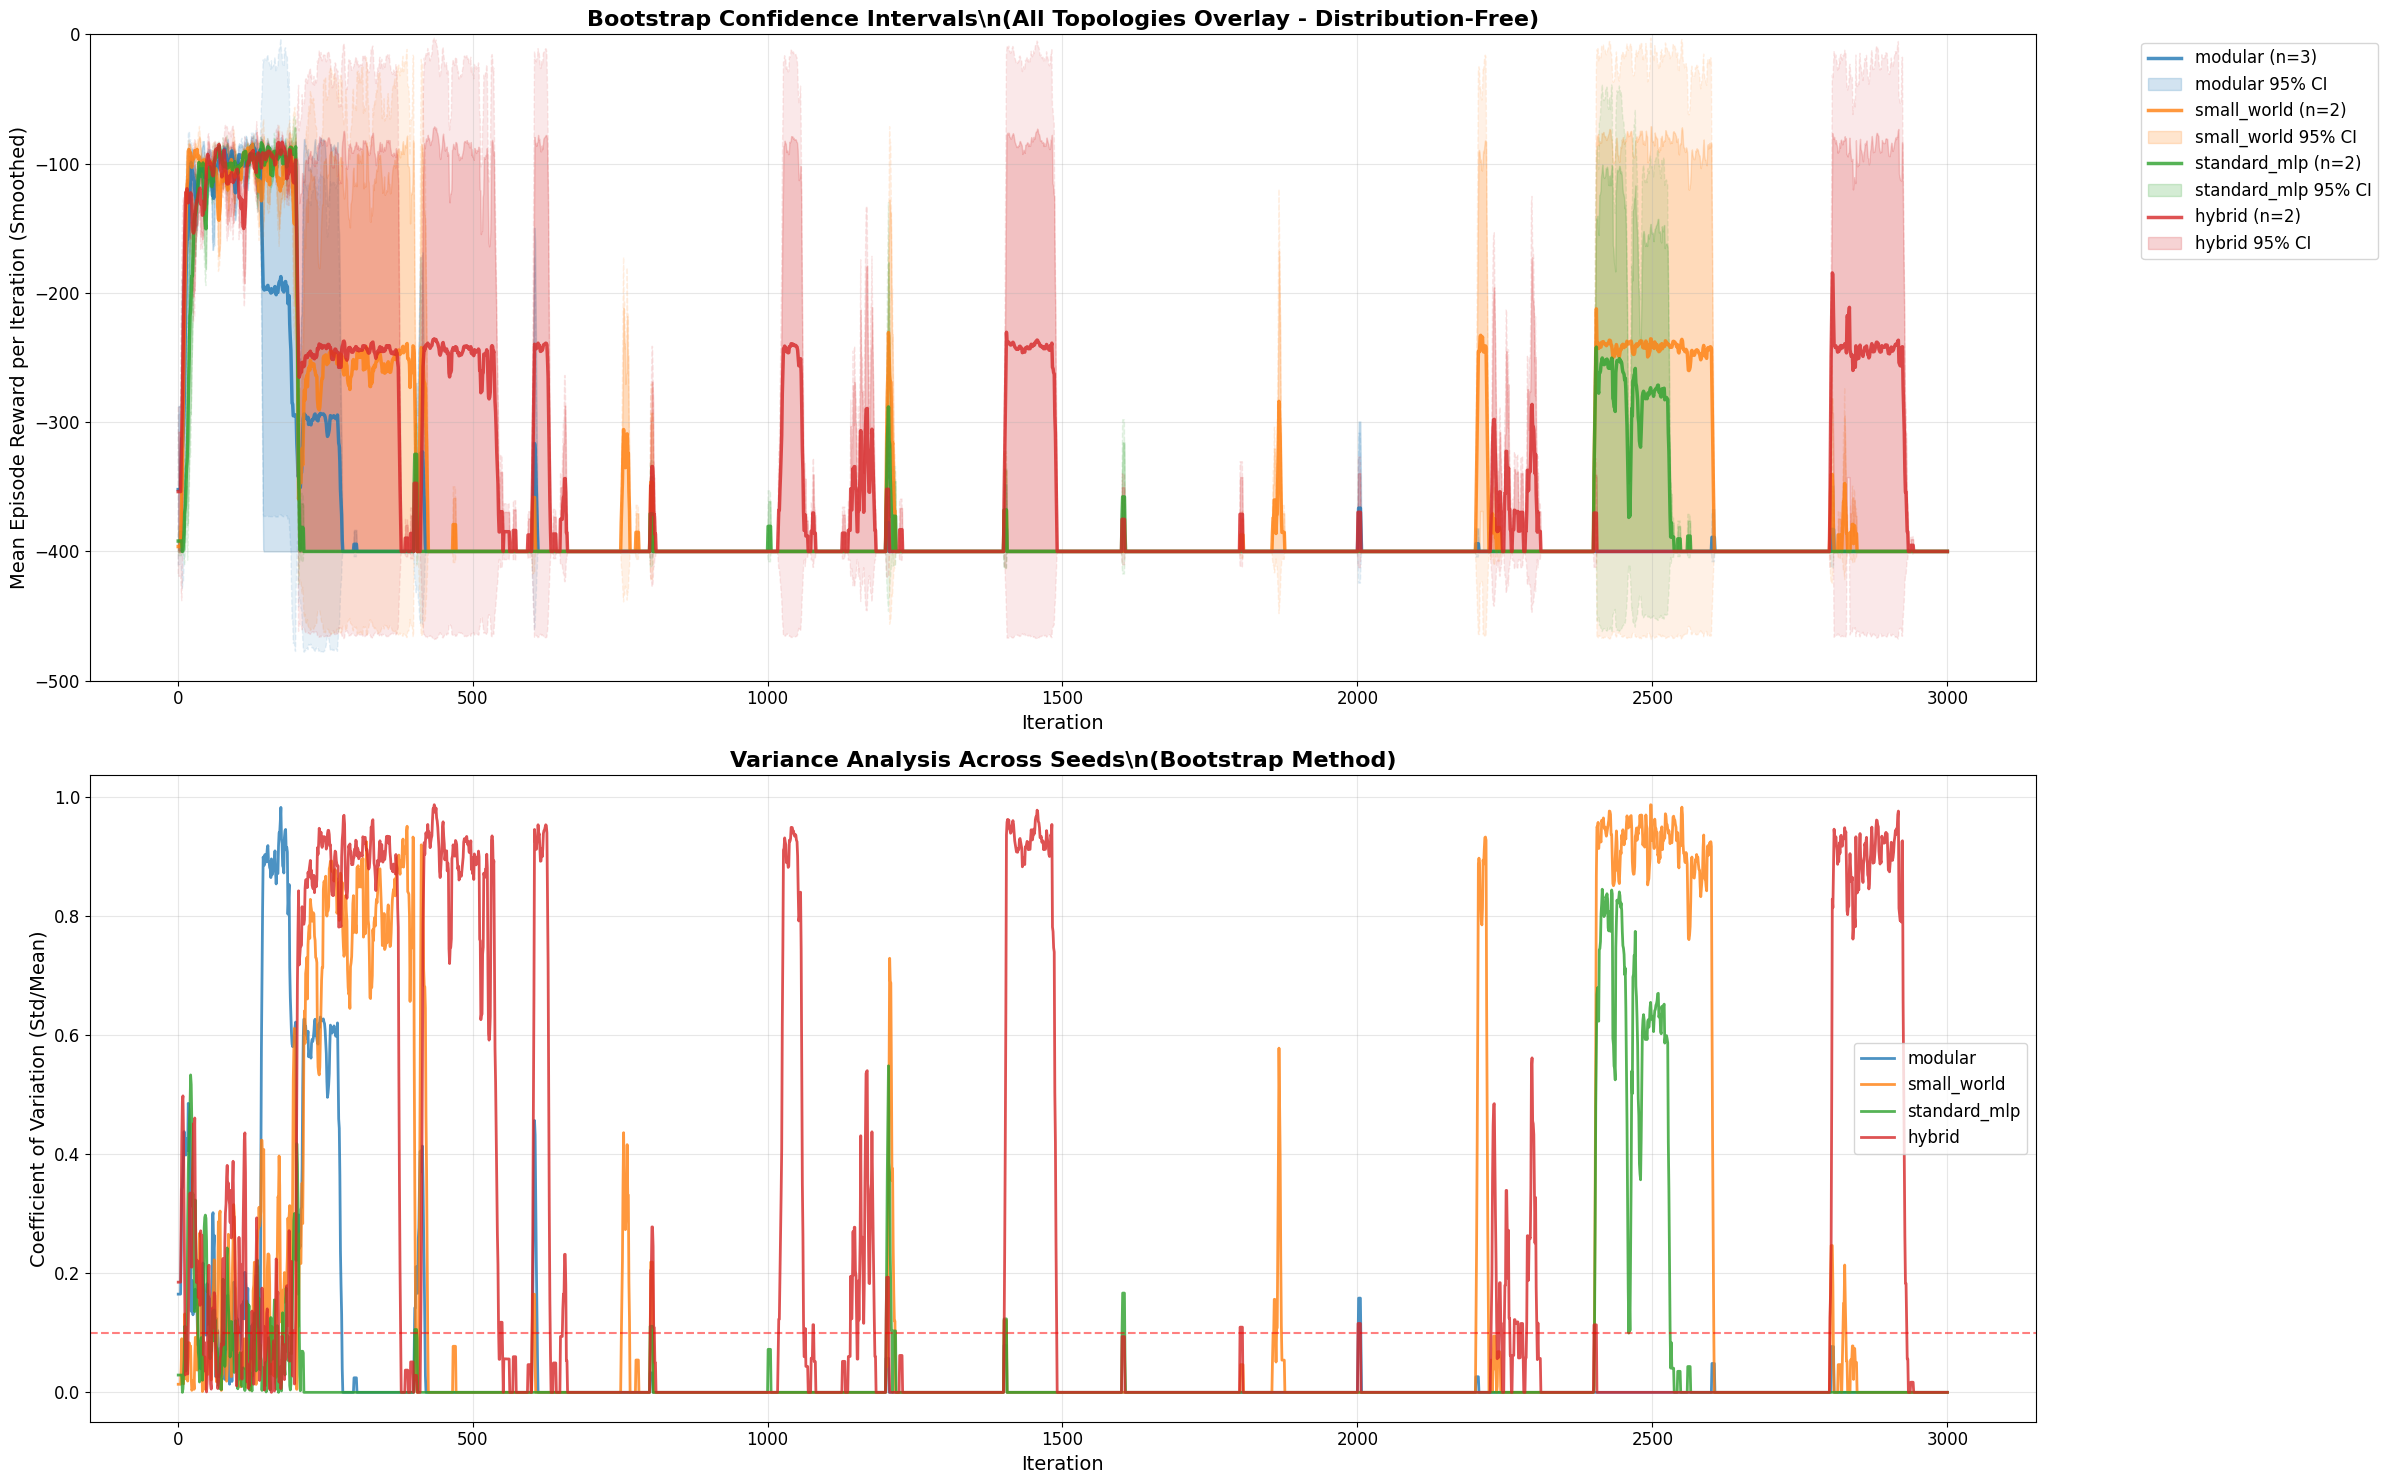

✅ Bootstrap Figure6 overlay plots generated


In [26]:
# ============================================================================
# OPTION 1: BOOTSTRAP CONFIDENCE INTERVALS (DISTRIBUTION-FREE)
# ============================================================================

def prepare_bootstrap_figure6_data(topology_groups: Dict) -> Dict:
    """Prepare data for Figure6 plots with bootstrap confidence intervals."""
    figure6_data = {}
    
    for topology_key, group in topology_groups.items():
        if len(group['runs']) < 2:
            print(f"⚠️  Skipping {topology_key}: Need at least 2 seeds for aggregation")
            continue
        
        # Extract iteration-based rewards for each seed
        seed_rewards = []
        max_iterations = 0
        
        for run in group['runs']:
            episode_data = run['episode_data']
            iteration_data = group_episodes_by_iteration(episode_data)
            
            if not iteration_data.empty and 'episode_return_raw' in iteration_data.columns:
                rewards = iteration_data['episode_return_raw'].values
                seed_rewards.append(rewards)
                max_iterations = max(max_iterations, len(rewards))
            else:
                print(f"⚠️  No valid iteration data in {run['folder']}")
        
        if not seed_rewards:
            continue
        
        # Pad arrays to same length and apply smoothing
        padded_rewards = []
        for rewards in seed_rewards:
            if len(rewards) < max_iterations:
                padded = np.pad(rewards, (0, max_iterations - len(rewards)), mode='edge')
            else:
                padded = rewards[:max_iterations]
            
            smoothed = apply_window_smoothing(padded, window=5)
            padded_rewards.append(smoothed)
        
        # Calculate bootstrap confidence intervals
        stats = calculate_bootstrap_confidence_intervals(padded_rewards)
        
        figure6_data[topology_key] = {
            'iterations': np.arange(1, max_iterations + 1),
            'mean_rewards': stats['mean'],
            'std_rewards': stats['std'],
            'var_rewards': stats['var'],
            'lower_bound': stats['lower_bound'],
            'upper_bound': stats['upper_bound'],
            'cv': stats['cv'],
            'num_seeds': stats['n_seeds'],
            'topology_type': group['topology_type'],
            'task_name': group['task_name']
        }
    
    return figure6_data

def plot_bootstrap_figure6_overlay(figure6_data: Dict):
    """Create Figure6 overlay plot with bootstrap confidence intervals."""
    if not figure6_data:
        print("❌ No Figure6 data available")
        return
    
    # Define colors for each topology
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
    
    # Create main overlay plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 15))
    
    # Plot 1: Overlay all topologies with bootstrap confidence intervals
    for i, (topology_key, data) in enumerate(figure6_data.items()):
        iterations = data['iterations']
        mean_rewards = data['mean_rewards']
        std_rewards = data['std_rewards']
        lower_bound = data['lower_bound']
        upper_bound = data['upper_bound']
        
        color = colors[i % len(colors)]
        
        # Plot mean line with transparency
        ax1.plot(iterations, mean_rewards, 
                label=f"{data['topology_type']} (n={data['num_seeds']})", 
                color=color, linewidth=2.5, alpha=0.8)
        
        # Plot bootstrap confidence interval with transparency
        ax1.fill_between(iterations, lower_bound, upper_bound, 
                        alpha=0.2, color=color, label=f"{data['topology_type']} 95% CI")
        
        # Plot standard deviation band
        ax1.fill_between(iterations, mean_rewards - std_rewards, mean_rewards + std_rewards, 
                        alpha=0.1, color=color, linestyle='--')
    
    ax1.set_xlabel('Iteration', fontsize=14)
    ax1.set_ylabel('Mean Episode Reward per Iteration (Smoothed)', fontsize=14)
    ax1.set_title('Bootstrap Confidence Intervals\\n(All Topologies Overlay - Distribution-Free)', fontsize=16, fontweight='bold')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(-500, 0)
    
    # Plot 2: Variance analysis
    for i, (topology_key, data) in enumerate(figure6_data.items()):
        iterations = data['iterations']
        cv = data['cv']
        
        color = colors[i % len(colors)]
        
        ax2.plot(iterations, cv, 
                label=f"{data['topology_type']}", 
                color=color, linewidth=2, alpha=0.8)
    
    ax2.set_xlabel('Iteration', fontsize=14)
    ax2.set_ylabel('Coefficient of Variation (Std/Mean)', fontsize=14)
    ax2.set_title('Variance Analysis Across Seeds\\n(Bootstrap Method)', fontsize=16, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='Low Variance Threshold')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Bootstrap Figure6 overlay plots generated")

# Prepare and plot bootstrap Figure6 data
print("🔄 Preparing bootstrap Figure6 data...")
bootstrap_figure6_data = prepare_bootstrap_figure6_data(topology_groups)
print(f"✅ Prepared bootstrap data for {len(bootstrap_figure6_data)} topology types")

# Generate bootstrap Figure6 plots
plot_bootstrap_figure6_overlay(bootstrap_figure6_data)


In [27]:
# ============================================================================
# OPTION 3: MEDIAN-BASED ANALYSIS (ROBUST TO OUTLIERS)
# ============================================================================

def calculate_median_statistics(data_arrays: List[np.ndarray], confidence: float = 0.95) -> Dict:
    """Calculate median-based statistics with percentile confidence intervals."""
    if not data_arrays:
        return {}
    
    # Stack arrays
    stacked = np.vstack(data_arrays)
    median = np.median(stacked, axis=0)
    mean = np.mean(stacked, axis=0)
    std = np.std(stacked, axis=0, ddof=1)
    var = np.var(stacked, axis=0, ddof=1)
    
    # Calculate percentiles for confidence intervals around median
    alpha = 1 - confidence
    lower_percentile = (alpha / 2) * 100
    upper_percentile = (1 - alpha / 2) * 100
    
    lower_bound = np.percentile(stacked, lower_percentile, axis=0)
    upper_bound = np.percentile(stacked, upper_percentile, axis=0)
    
    # Calculate median absolute deviation (MAD) as robust measure of spread
    mad = np.median(np.abs(stacked - median), axis=0)
    
    return {
        'median': median,
        'mean': mean,
        'std': std,
        'var': var,
        'mad': mad,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'n_seeds': len(data_arrays),
        'cv': std / np.abs(mean + 1e-8),  # Still use mean for CV
        'mad_cv': mad / np.abs(median + 1e-8)  # MAD-based coefficient of variation
    }

print("✅ Median-based statistics function defined")


✅ Median-based statistics function defined


🔄 Preparing median Figure6 data...
✅ Prepared median data for 4 topology types


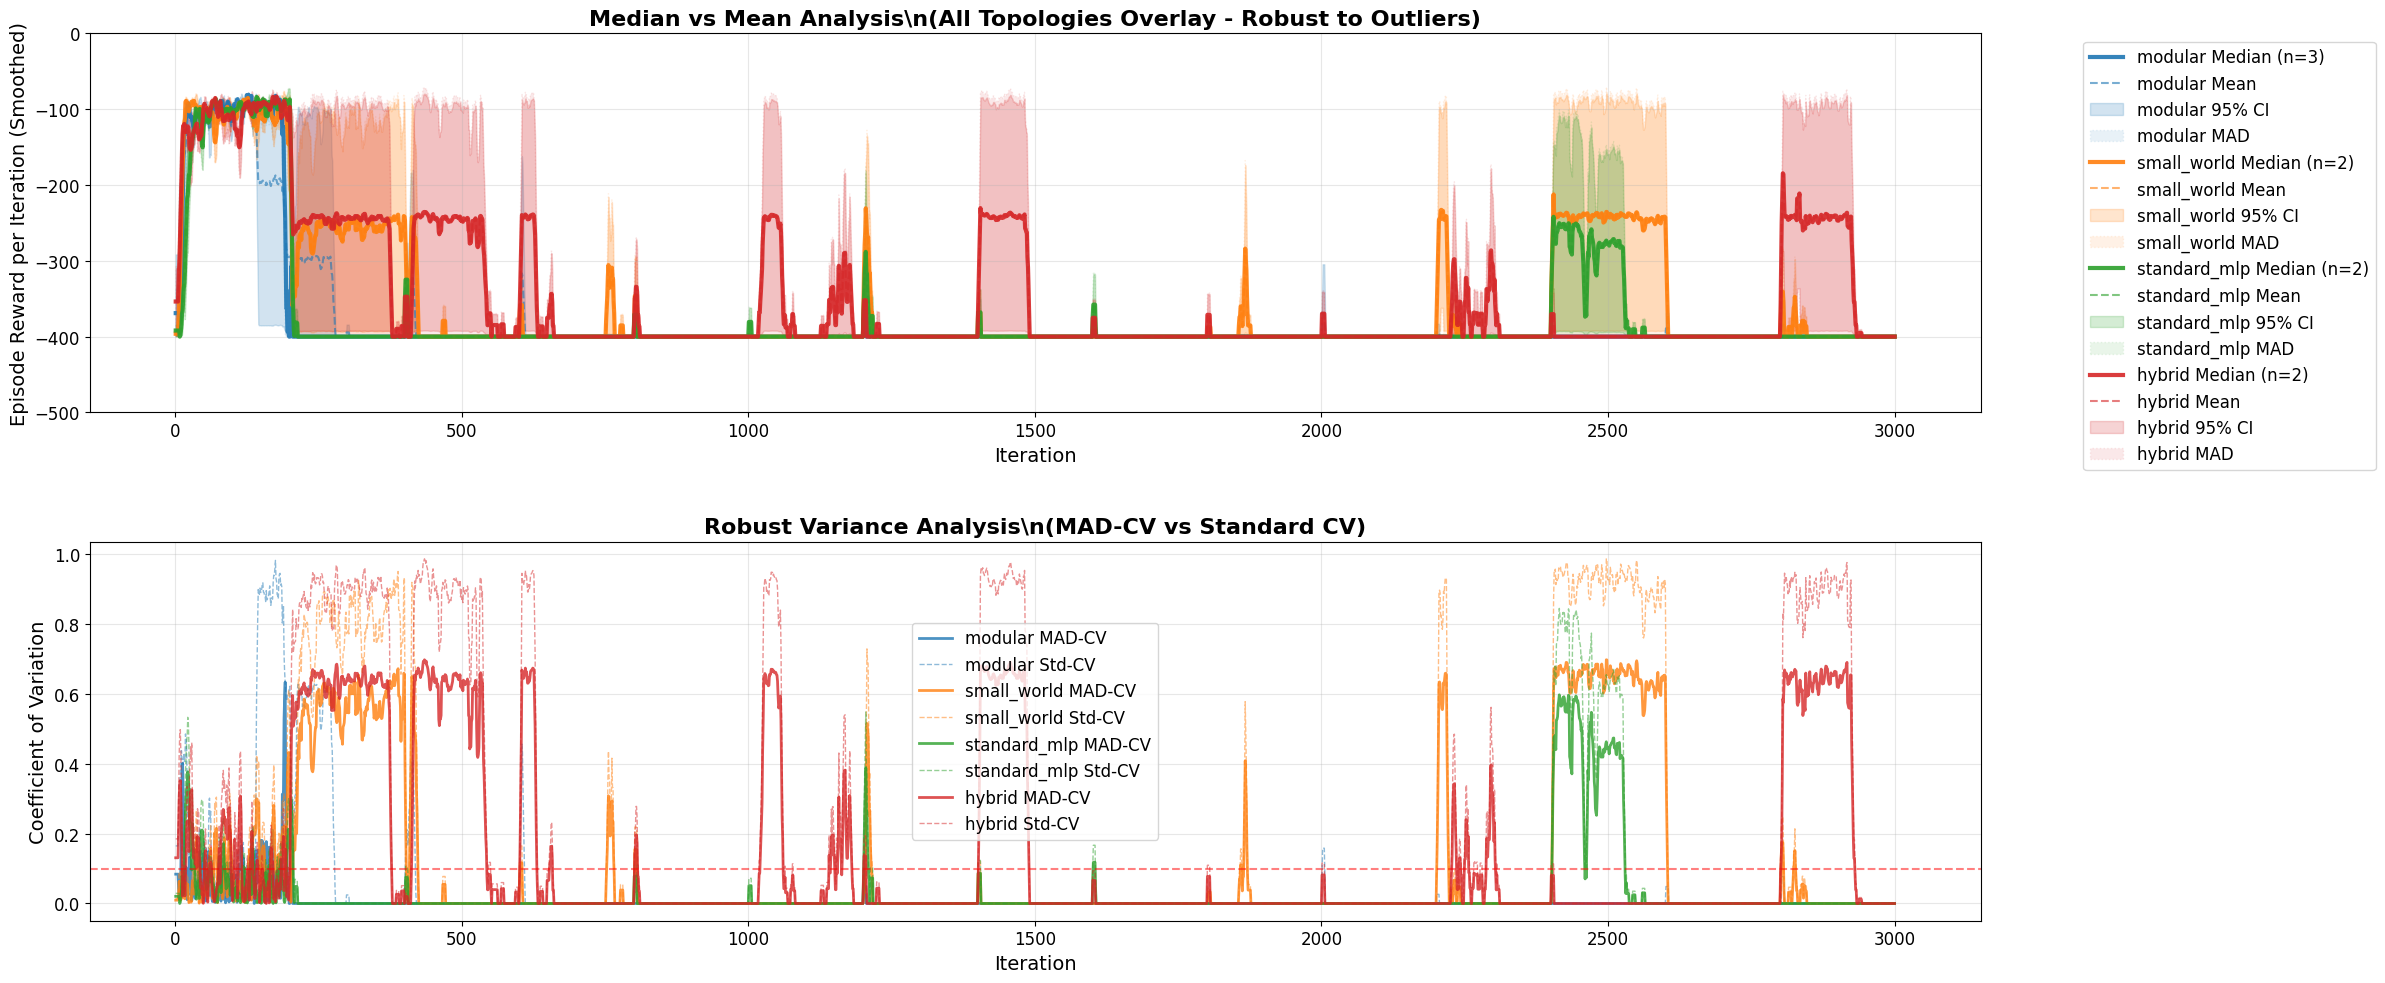

✅ Median-based Figure6 overlay plots generated


In [28]:
def prepare_median_figure6_data(topology_groups: Dict) -> Dict:
    """Prepare data for Figure6 plots with median-based analysis."""
    figure6_data = {}
    
    for topology_key, group in topology_groups.items():
        if len(group['runs']) < 2:
            print(f"⚠️  Skipping {topology_key}: Need at least 2 seeds for aggregation")
            continue
        
        # Extract iteration-based rewards for each seed
        seed_rewards = []
        max_iterations = 0
        
        for run in group['runs']:
            episode_data = run['episode_data']
            iteration_data = group_episodes_by_iteration(episode_data)
            
            if not iteration_data.empty and 'episode_return_raw' in iteration_data.columns:
                rewards = iteration_data['episode_return_raw'].values
                seed_rewards.append(rewards)
                max_iterations = max(max_iterations, len(rewards))
            else:
                print(f"⚠️  No valid iteration data in {run['folder']}")
        
        if not seed_rewards:
            continue
        
        # Pad arrays to same length and apply smoothing
        padded_rewards = []
        for rewards in seed_rewards:
            if len(rewards) < max_iterations:
                padded = np.pad(rewards, (0, max_iterations - len(rewards)), mode='edge')
            else:
                padded = rewards[:max_iterations]
            
            smoothed = apply_window_smoothing(padded, window=5)
            padded_rewards.append(smoothed)
        
        # Calculate median-based statistics
        stats = calculate_median_statistics(padded_rewards)
        
        figure6_data[topology_key] = {
            'iterations': np.arange(1, max_iterations + 1),
            'median_rewards': stats['median'],
            'mean_rewards': stats['mean'],
            'std_rewards': stats['std'],
            'var_rewards': stats['var'],
            'mad_rewards': stats['mad'],
            'lower_bound': stats['lower_bound'],
            'upper_bound': stats['upper_bound'],
            'cv': stats['cv'],
            'mad_cv': stats['mad_cv'],
            'num_seeds': stats['n_seeds'],
            'topology_type': group['topology_type'],
            'task_name': group['task_name']
        }
    
    return figure6_data

def plot_median_figure6_overlay(figure6_data: Dict):
    """Create Figure6 overlay plot with median-based analysis."""
    if not figure6_data:
        print("❌ No Figure6 data available")
        return
    
    # Define colors for each topology
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
    
    # Create main overlay plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 10))
    
    # Plot 1: Overlay all topologies with median lines
    for i, (topology_key, data) in enumerate(figure6_data.items()):
        iterations = data['iterations']
        median_rewards = data['median_rewards']
        mean_rewards = data['mean_rewards']
        mad_rewards = data['mad_rewards']
        lower_bound = data['lower_bound']
        upper_bound = data['upper_bound']
        
        color = colors[i % len(colors)]
        
        # Plot median line with transparency (thicker line)
        ax1.plot(iterations, median_rewards, 
                label=f"{data['topology_type']} Median (n={data['num_seeds']})", 
                color=color, linewidth=3, alpha=0.9, linestyle='-')
        
        # Plot mean line with transparency (thinner line)
        ax1.plot(iterations, mean_rewards, 
                label=f"{data['topology_type']} Mean", 
                color=color, linewidth=1.5, alpha=0.6, linestyle='--')
        
        # Plot percentile confidence interval with transparency
        ax1.fill_between(iterations, lower_bound, upper_bound, 
                        alpha=0.2, color=color, label=f"{data['topology_type']} 95% CI")
        
        # Plot MAD band (robust measure of spread)
        ax1.fill_between(iterations, median_rewards - mad_rewards, median_rewards + mad_rewards, 
                        alpha=0.1, color=color, linestyle=':', label=f"{data['topology_type']} MAD")
    
    ax1.set_xlabel('Iteration', fontsize=14)
    ax1.set_ylabel('Episode Reward per Iteration (Smoothed)', fontsize=14)
    ax1.set_title('Median vs Mean Analysis\\n(All Topologies Overlay - Robust to Outliers)', fontsize=16, fontweight='bold')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(-500, 0)
    
    # Plot 2: Robust variance analysis (MAD-based)
    for i, (topology_key, data) in enumerate(figure6_data.items()):
        iterations = data['iterations']
        mad_cv = data['mad_cv']  # MAD-based coefficient of variation
        cv = data['cv']  # Standard CV
        
        color = colors[i % len(colors)]
        
        # Plot both MAD-CV and standard CV
        ax2.plot(iterations, mad_cv, 
                label=f"{data['topology_type']} MAD-CV", 
                color=color, linewidth=2, alpha=0.8, linestyle='-')
        
        ax2.plot(iterations, cv, 
                label=f"{data['topology_type']} Std-CV", 
                color=color, linewidth=1, alpha=0.5, linestyle='--')
    
    ax2.set_xlabel('Iteration', fontsize=14)
    ax2.set_ylabel('Coefficient of Variation', fontsize=14)
    ax2.set_title('Robust Variance Analysis\\n(MAD-CV vs Standard CV)', fontsize=16, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='Low Variance Threshold')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Median-based Figure6 overlay plots generated")

# Prepare and plot median Figure6 data
print("🔄 Preparing median Figure6 data...")
median_figure6_data = prepare_median_figure6_data(topology_groups)
print(f"✅ Prepared median data for {len(median_figure6_data)} topology types")

# Generate median Figure6 plots
plot_median_figure6_overlay(median_figure6_data)


🔄 Preparing median Figure6 data...
✅ Prepared median data for 4 topology types


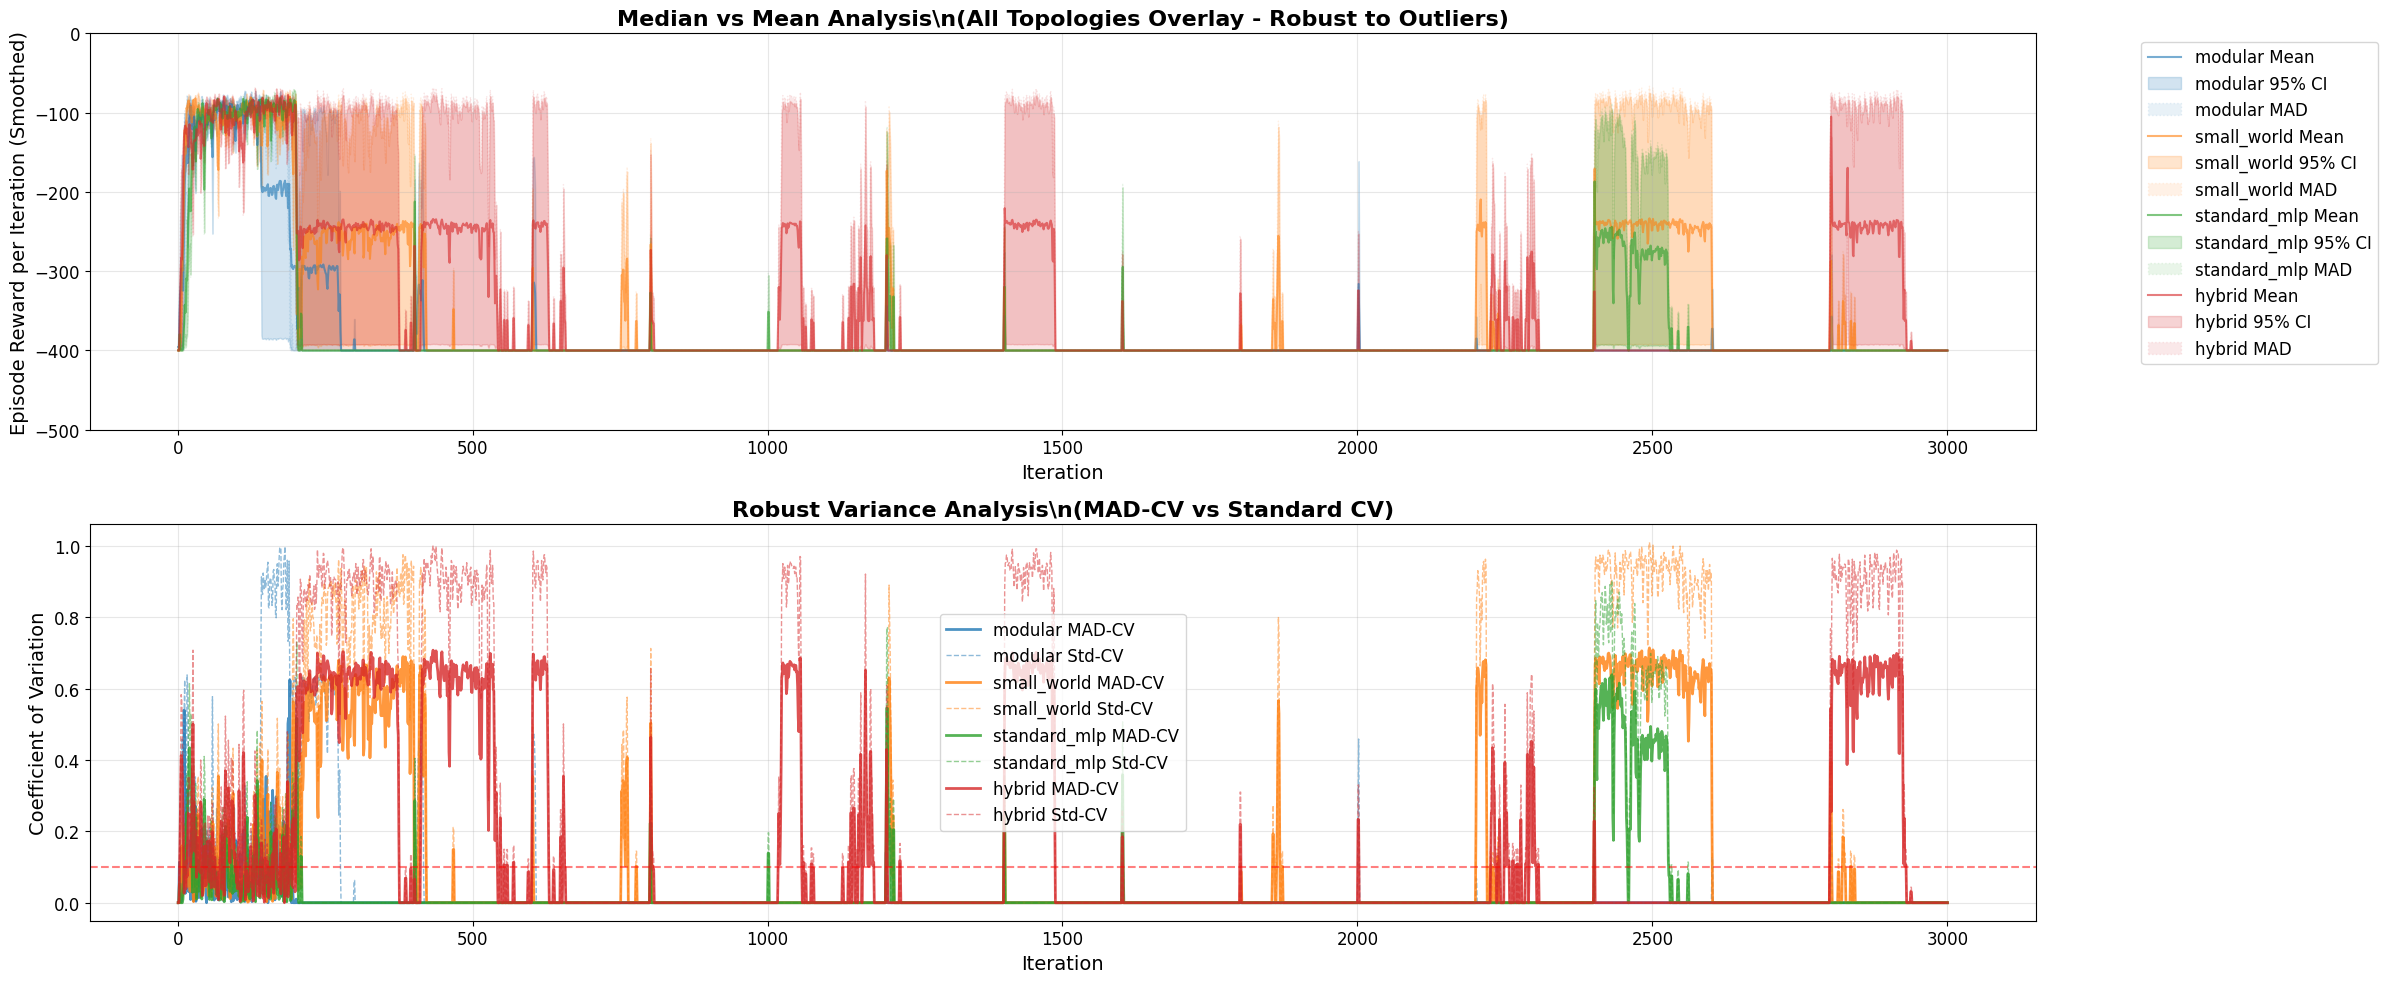

✅ Median-based Figure6 overlay plots generated


In [29]:
def prepare_median_figure6_data(topology_groups: Dict) -> Dict:
    """Prepare data for Figure6 plots with median-based analysis."""
    figure6_data = {}
    
    for topology_key, group in topology_groups.items():
        if len(group['runs']) < 2:
            print(f"⚠️  Skipping {topology_key}: Need at least 2 seeds for aggregation")
            continue
        
        # Extract iteration-based rewards for each seed
        seed_rewards = []
        max_iterations = 0
        
        for run in group['runs']:
            episode_data = run['episode_data']
            iteration_data = group_episodes_by_iteration(episode_data)
            
            if not iteration_data.empty and 'episode_return_raw' in iteration_data.columns:
                rewards = iteration_data['episode_return_raw'].values
                seed_rewards.append(rewards)
                max_iterations = max(max_iterations, len(rewards))
            else:
                print(f"⚠️  No valid iteration data in {run['folder']}")
        
        if not seed_rewards:
            continue
        
        # Pad arrays to same length and apply smoothing
        padded_rewards = []
        for rewards in seed_rewards:
            if len(rewards) < max_iterations:
                padded = np.pad(rewards, (0, max_iterations - len(rewards)), mode='edge')
            else:
                padded = rewards[:max_iterations]
            
            smoothed = apply_window_smoothing(padded, window=2)
            padded_rewards.append(smoothed)
        
        # Calculate median-based statistics
        stats = calculate_median_statistics(padded_rewards)
        
        figure6_data[topology_key] = {
            'iterations': np.arange(1, max_iterations + 1),
            'median_rewards': stats['median'],
            'mean_rewards': stats['mean'],
            'std_rewards': stats['std'],
            'var_rewards': stats['var'],
            'mad_rewards': stats['mad'],
            'lower_bound': stats['lower_bound'],
            'upper_bound': stats['upper_bound'],
            'cv': stats['cv'],
            'mad_cv': stats['mad_cv'],
            'num_seeds': stats['n_seeds'],
            'topology_type': group['topology_type'],
            'task_name': group['task_name']
        }
    
    return figure6_data

def plot_median_figure6_overlay(figure6_data: Dict):
    """Create Figure6 overlay plot with median-based analysis."""
    if not figure6_data:
        print("❌ No Figure6 data available")
        return
    
    # Define colors for each topology
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
    
    # Create main overlay plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 10))
    
    # Plot 1: Overlay all topologies with median lines
    for i, (topology_key, data) in enumerate(figure6_data.items()):
        iterations = data['iterations']
        median_rewards = data['median_rewards']
        mean_rewards = data['mean_rewards']
        mad_rewards = data['mad_rewards']
        lower_bound = data['lower_bound']
        upper_bound = data['upper_bound']
        
        color = colors[i % len(colors)]
        
        """
        # Plot median line with transparency (thicker line)
        ax1.plot(iterations, median_rewards, 
                label=f"{data['topology_type']} Median (n={data['num_seeds']})", 
                color=color, linewidth=3, alpha=0.9, linestyle='-')
        
        """
        
        # Plot mean line with transparency (thinner line)
        ax1.plot(iterations, mean_rewards, 
                label=f"{data['topology_type']} Mean", 
                color=color, linewidth=1.5, alpha=0.6)
        


        # Plot percentile confidence interval with transparency
        ax1.fill_between(iterations, lower_bound, upper_bound, 
                        alpha=0.2, color=color, label=f"{data['topology_type']} 95% CI")
        
        # Plot MAD band (robust measure of spread)
        ax1.fill_between(iterations, median_rewards - mad_rewards, median_rewards + mad_rewards, 
                        alpha=0.1, color=color, linestyle=':', label=f"{data['topology_type']} MAD")
    
    ax1.set_xlabel('Iteration', fontsize=14)
    ax1.set_ylabel('Episode Reward per Iteration (Smoothed)', fontsize=14)
    ax1.set_title('Median vs Mean Analysis\\n(All Topologies Overlay - Robust to Outliers)', fontsize=16, fontweight='bold')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(-500, 0)
    
    # Plot 2: Robust variance analysis (MAD-based)
    for i, (topology_key, data) in enumerate(figure6_data.items()):
        iterations = data['iterations']
        mad_cv = data['mad_cv']  # MAD-based coefficient of variation
        cv = data['cv']  # Standard CV
        
        color = colors[i % len(colors)]
        
        # Plot both MAD-CV and standard CV
        ax2.plot(iterations, mad_cv, 
                label=f"{data['topology_type']} MAD-CV", 
                color=color, linewidth=2, alpha=0.8, linestyle='-')
        
        ax2.plot(iterations, cv, 
                label=f"{data['topology_type']} Std-CV", 
                color=color, linewidth=1, alpha=0.5, linestyle='--')
    
    ax2.set_xlabel('Iteration', fontsize=14)
    ax2.set_ylabel('Coefficient of Variation', fontsize=14)
    ax2.set_title('Robust Variance Analysis\\n(MAD-CV vs Standard CV)', fontsize=16, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='Low Variance Threshold')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Median-based Figure6 overlay plots generated")

# Prepare and plot median Figure6 data
print("🔄 Preparing median Figure6 data...")
median_figure6_data = prepare_median_figure6_data(topology_groups)
print(f"✅ Prepared median data for {len(median_figure6_data)} topology types")

# Generate median Figure6 plots
plot_median_figure6_overlay(median_figure6_data)

🔄 Preparing percentile Figure6 data...
✅ Prepared percentile data for 4 topology types


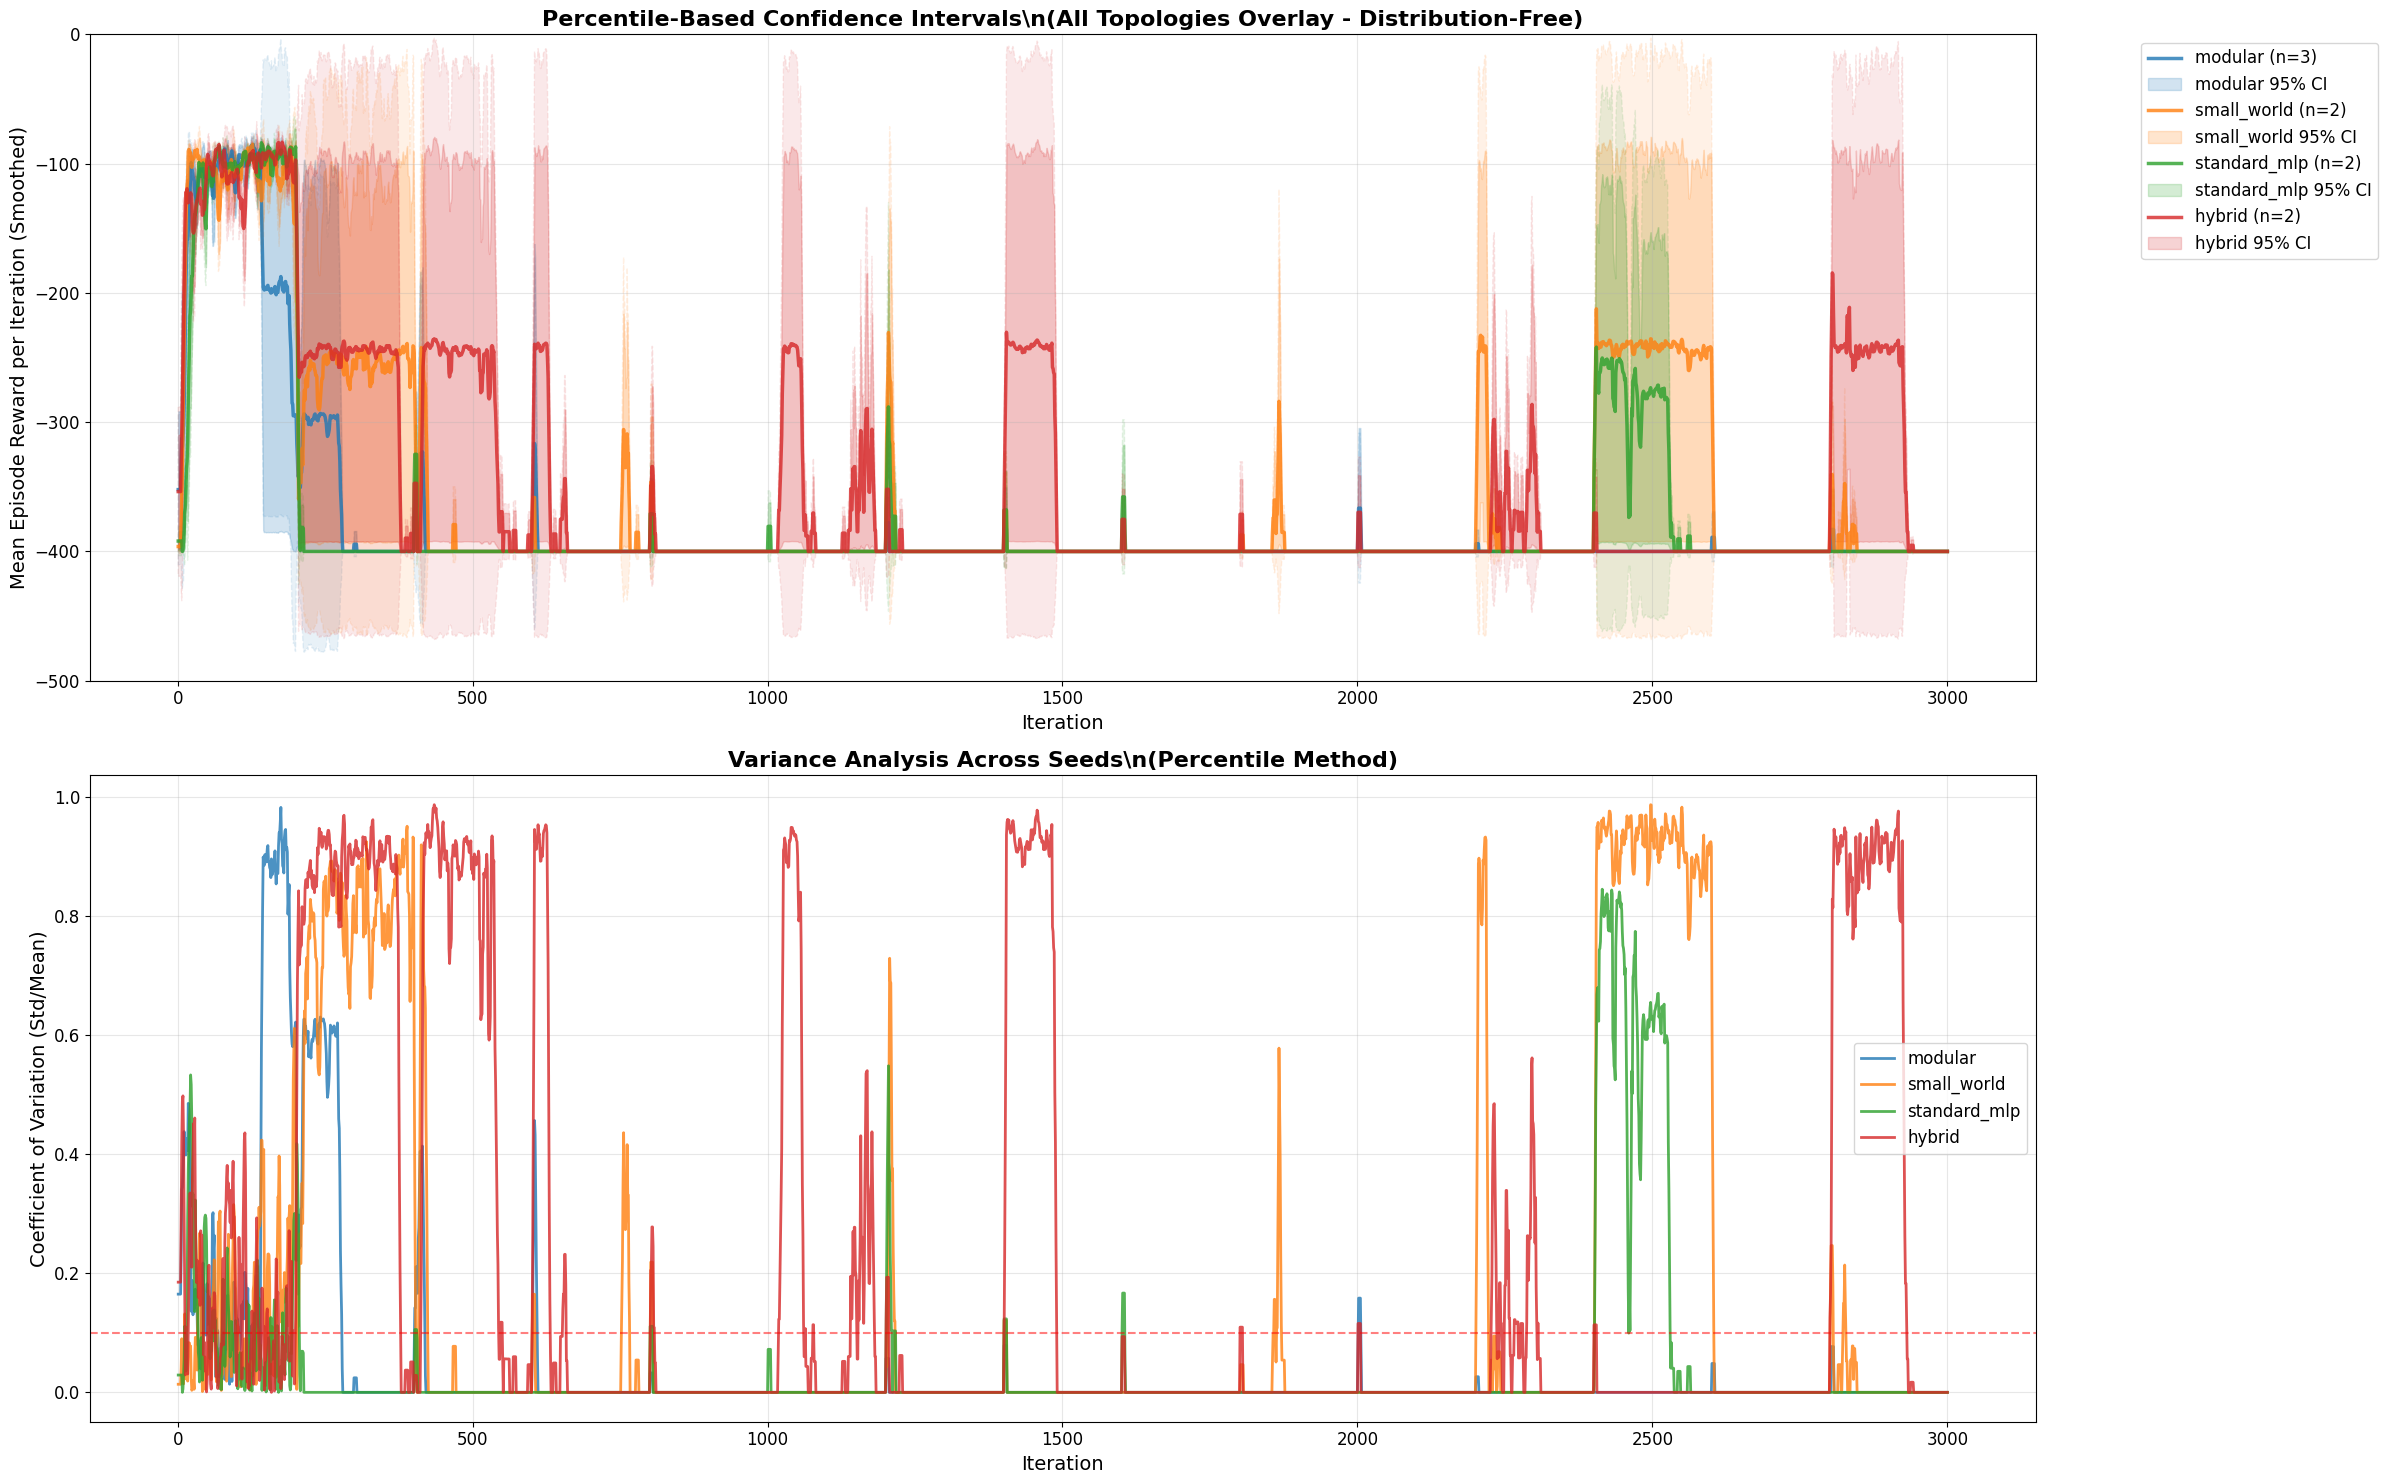

✅ Percentile-based Figure6 overlay plots generated


In [30]:
# ============================================================================
# OPTION 2: PERCENTILE-BASED CONFIDENCE INTERVALS (DISTRIBUTION-FREE)
# ============================================================================

def prepare_percentile_figure6_data(topology_groups: Dict) -> Dict:
    """Prepare data for Figure6 plots with percentile-based confidence intervals."""
    figure6_data = {}
    
    for topology_key, group in topology_groups.items():
        if len(group['runs']) < 2:
            print(f"⚠️  Skipping {topology_key}: Need at least 2 seeds for aggregation")
            continue
        
        # Extract iteration-based rewards for each seed
        seed_rewards = []
        max_iterations = 0
        
        for run in group['runs']:
            episode_data = run['episode_data']
            iteration_data = group_episodes_by_iteration(episode_data)
            
            if not iteration_data.empty and 'episode_return_raw' in iteration_data.columns:
                rewards = iteration_data['episode_return_raw'].values
                seed_rewards.append(rewards)
                max_iterations = max(max_iterations, len(rewards))
            else:
                print(f"⚠️  No valid iteration data in {run['folder']}")
        
        if not seed_rewards:
            continue
        
        # Pad arrays to same length and apply smoothing
        padded_rewards = []
        for rewards in seed_rewards:
            if len(rewards) < max_iterations:
                padded = np.pad(rewards, (0, max_iterations - len(rewards)), mode='edge')
            else:
                padded = rewards[:max_iterations]
            
            smoothed = apply_window_smoothing(padded, window=5)
            padded_rewards.append(smoothed)
        
        # Calculate percentile-based confidence intervals
        stats = calculate_percentile_intervals(padded_rewards)
        
        figure6_data[topology_key] = {
            'iterations': np.arange(1, max_iterations + 1),
            'mean_rewards': stats['mean'],
            'std_rewards': stats['std'],
            'var_rewards': stats['var'],
            'lower_bound': stats['lower_bound'],
            'upper_bound': stats['upper_bound'],
            'cv': stats['cv'],
            'num_seeds': stats['n_seeds'],
            'topology_type': group['topology_type'],
            'task_name': group['task_name']
        }
    
    return figure6_data

def plot_percentile_figure6_overlay(figure6_data: Dict):
    """Create Figure6 overlay plot with percentile-based confidence intervals."""
    if not figure6_data:
        print("❌ No Figure6 data available")
        return
    
    # Define colors for each topology
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
    
    # Create main overlay plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 15))
    
    # Plot 1: Overlay all topologies with percentile confidence intervals
    for i, (topology_key, data) in enumerate(figure6_data.items()):
        iterations = data['iterations']
        mean_rewards = data['mean_rewards']
        std_rewards = data['std_rewards']
        lower_bound = data['lower_bound']
        upper_bound = data['upper_bound']
        
        color = colors[i % len(colors)]
        
        # Plot mean line with transparency
        ax1.plot(iterations, mean_rewards, 
                label=f"{data['topology_type']} (n={data['num_seeds']})", 
                color=color, linewidth=2.5, alpha=0.8)
        
        # Plot percentile confidence interval with transparency
        ax1.fill_between(iterations, lower_bound, upper_bound, 
                        alpha=0.2, color=color, label=f"{data['topology_type']} 95% CI")
        
        # Plot standard deviation band
        ax1.fill_between(iterations, mean_rewards - std_rewards, mean_rewards + std_rewards, 
                        alpha=0.1, color=color, linestyle='--')
    
    ax1.set_xlabel('Iteration', fontsize=14)
    ax1.set_ylabel('Mean Episode Reward per Iteration (Smoothed)', fontsize=14)
    ax1.set_title('Percentile-Based Confidence Intervals\\n(All Topologies Overlay - Distribution-Free)', fontsize=16, fontweight='bold')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(-500, 0)
    
    # Plot 2: Variance analysis
    for i, (topology_key, data) in enumerate(figure6_data.items()):
        iterations = data['iterations']
        cv = data['cv']
        
        color = colors[i % len(colors)]
        
        ax2.plot(iterations, cv, 
                label=f"{data['topology_type']}", 
                color=color, linewidth=2, alpha=0.8)
    
    ax2.set_xlabel('Iteration', fontsize=14)
    ax2.set_ylabel('Coefficient of Variation (Std/Mean)', fontsize=14)
    ax2.set_title('Variance Analysis Across Seeds\\n(Percentile Method)', fontsize=16, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='Low Variance Threshold')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Percentile-based Figure6 overlay plots generated")

# Prepare and plot percentile Figure6 data
print("🔄 Preparing percentile Figure6 data...")
percentile_figure6_data = prepare_percentile_figure6_data(topology_groups)
print(f"✅ Prepared percentile data for {len(percentile_figure6_data)} topology types")

# Generate percentile Figure6 plots
plot_percentile_figure6_overlay(percentile_figure6_data)
